In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Load dataset from CSV file
df = pd.read_csv(r"C:\Users\Shantanu\Downloads\insurance.csv")

In [3]:
df.head() # Display first 5 rows of dataset

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info() #dataset structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe() #statistical summary

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.isnull() #check for null values

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1}) #caEagorical conversion

In [9]:
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

In [10]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)     #one hot encoding

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int64  
 5   charges           1338 non-null   float64
 6   region_northwest  1338 non-null   bool   
 7   region_southeast  1338 non-null   bool   
 8   region_southwest  1338 non-null   bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 66.8 KB


In [12]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [13]:
X = df.drop('charges', axis=1)    #independent Variable
y = df['charges']                 #dependent variable

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   #spliting data

In [15]:
#linear Regression

In [16]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [17]:
lr.fit(X_train, y_train)  #to train the model

LinearRegression()

In [18]:
y_pred = lr.predict(X_test)   #prediction on test data

In [19]:
#Model Evaluation using sklearn

In [20]:
mse = mean_squared_error(y_test, y_pred)   #calculating error actual VS predicted
rmse = np.sqrt(mse)                        #root MSE

In [21]:
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 33596915.85136144
RMSE: 5796.284659276271


In [22]:
#this means model will predict + or - 5800 value on actual value

In [23]:
print(X_train.dtypes)

age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object


In [24]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [25]:
print(X_train.dtypes)

age                 float64
sex                 float64
bmi                 float64
children            float64
smoker              float64
region_northwest    float64
region_southeast    float64
region_southwest    float64
dtype: object


In [26]:
#OLS model

In [27]:
#constant for train and test data
X_train_sm = sm.add_constant(X_train) 
X_test_sm = sm.add_constant(X_test)

In [28]:
ols_model = sm.OLS(y_train, X_train_sm).fit()  #creating OLS model

In [29]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     380.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.32e-305
Time:                        16:25:57   Log-Likelihood:                -10845.
No. Observations:                1070   AIC:                         2.171e+04
Df Residuals:                    1061   BIC:                         2.175e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.195e+04   1121.021  

In [30]:
y_pred_ols = ols_model.predict(X_test_sm)   #prediction using OLS model

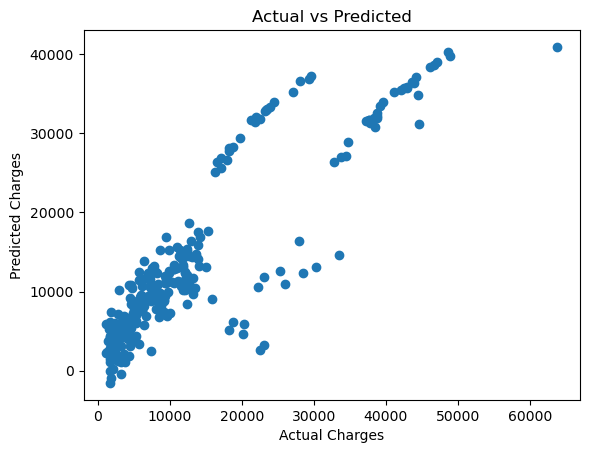

In [32]:
# Scatter plot for actual vs predicted values
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted")

plt.show()